# Diabetes Model Creation and Usage 

In [18]:
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

EXPERIMENT_NAME = "diabetes-prediction-experiment"
REGISTERED_MODEL_NAME = "diabetes_prediction_model"
RANDOM_SEED = 42

mlflow.set_experiment(EXPERIMENT_NAME)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 45, Finished, Available, Finished, False)

2026/08/03 02:18:38 INFO mlflow.tracking.fluent: Experiment with name 'diabetes-prediction-experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='sds://onelakemsit.pbidedicated.windows.net/63cdb0e4-d789-4a69-8d41-093baad72a7f/e8c31eda-6753-435a-9af6-dff072ba4431', creation_time=1785723520487, experiment_id='e8c31eda-6753-435a-9af6-dff072ba4431', last_update_time=1785723520487, lifecycle_stage='active', name='diabetes-prediction-experiment', tags={}>

In [19]:
def create_diabetes_data(rows=5_000, seed=42, include_target=True):
    rng = np.random.default_rng(seed)

    data = pd.DataFrame({
        "age": rng.integers(18, 85, rows),
        "bmi": np.clip(rng.normal(28, 6, rows), 15, 50).round(1),
        "glucose": np.clip(rng.normal(110, 30, rows), 55, 250).round(1),
        "blood_pressure": np.clip(rng.normal(75, 12, rows), 40, 130).round(1),
        "insulin": np.clip(rng.lognormal(4.3, 0.7, rows), 10, 500).round(1),
        "waist_cm": np.clip(rng.normal(90, 15, rows), 55, 150).round(1),
        "family_history": rng.binomial(1, 0.35, rows),
        "hypertension": rng.binomial(1, 0.25, rows),
        "physical_activity_hours": np.clip(
            rng.normal(3.5, 2, rows), 0, 14
        ).round(1),
    })

    if include_target:
        risk_score = (
            -8.0
            + 0.035 * data["age"]
            + 0.040 * data["bmi"]
            + 0.009 * data["glucose"]
            + 0.015 * data["waist_cm"]
            + 0.50 * data["family_history"]
            + 0.30 * data["hypertension"]
            - 0.10 * data["physical_activity_hours"]
        )

        probability = 1 / (1 + np.exp(-risk_score))
        data["diabetes"] = rng.binomial(1, probability)

    return data


diabetes_data = create_diabetes_data(rows=5_000, seed=RANDOM_SEED)

display(diabetes_data.head())
print(diabetes_data["diabetes"].value_counts(normalize=True))

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 47, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 69cdf86a-5eec-4cbe-8a3f-eaa2cd377418)

diabetes
0    0.9264
1    0.0736
Name: proportion, dtype: float64


In [20]:
X = diabetes_data.drop(columns="diabetes")
y = diabetes_data["diabetes"]

X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Validation rows: {len(X_validation)}")

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 49, Finished, Available, Finished, False)

Training rows: 4000
Validation rows: 1000


In [21]:
model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1_000,
            class_weight="balanced",
            random_state=RANDOM_SEED,
        ),
    ),
])

with mlflow.start_run(run_name="logistic-regression") as run:
    model.fit(X_train, y_train)

    predictions = model.predict(X_validation)
    probabilities = model.predict_proba(X_validation)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_validation, predictions),
        "roc_auc": roc_auc_score(y_validation, probabilities),
    }

    mlflow.log_params({
        "algorithm": "LogisticRegression",
        "training_rows": len(X_train),
        "validation_rows": len(X_validation),
        "class_weight": "balanced",
        "random_seed": RANDOM_SEED,
    })

    mlflow.log_metrics(metrics)

    signature = infer_signature(
        X_train,
        model.predict(X_train),
    )

    model_info = mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_train.head(5),
        registered_model_name=REGISTERED_MODEL_NAME,
    )

    run_id = run.info.run_id
    saved_model_uri = model_info.model_uri

print("Run ID:", run_id)
print("Model URI:", saved_model_uri)
print("Metrics:", metrics)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 51, Finished, Available, Finished, False)

2026/08/03 02:19:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/03 02:19:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/trusted-serv

Run ID: 0f7ff542-a54a-451d-a918-b1ca5d28782f
Model URI: runs:/0f7ff542-a54a-451d-a918-b1ca5d28782f/model
Metrics: {'accuracy': 0.641, 'roc_auc': 0.687671472768665}


In [22]:
print(classification_report(y_validation, predictions))

confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_validation, predictions),
    index=["Actual No Diabetes", "Actual Diabetes"],
    columns=["Predicted No Diabetes", "Predicted Diabetes"],
)

display(confusion_matrix_df)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 53, Finished, Available, Finished, False)

              precision    recall  f1-score   support

           0       0.96      0.64      0.77       926
           1       0.12      0.62      0.20        74

    accuracy                           0.64      1000
   macro avg       0.54      0.63      0.49      1000
weighted avg       0.89      0.64      0.73      1000



SynapseWidget(Synapse.DataFrame, 84437973-7b19-4e81-9713-530ccd6dc7d6)

In [23]:
new_patient_data = create_diabetes_data(
    rows=20,
    seed=2026,
    include_target=False,
)

display(new_patient_data)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 54, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 0d8b7a6b-5152-4139-9223-458032001551)

In [24]:
loaded_model = mlflow.sklearn.load_model(saved_model_uri)

prediction_results = new_patient_data.copy()
prediction_results["predicted_diabetes"] = loaded_model.predict(
    new_patient_data
)
prediction_results["diabetes_probability"] = loaded_model.predict_proba(
    new_patient_data
)[:, 1]

prediction_results["risk_category"] = pd.cut(
    prediction_results["diabetes_probability"],
    bins=[-0.01, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"],
)

display(
    prediction_results.sort_values(
        "diabetes_probability",
        ascending=False,
    )
)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 55, Finished, Available, Finished, False)

2026/08/03 02:20:52 INFO mlflow.store.artifact.artifact_repo: The progress bar can be disabled by setting the environment variable MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR to false
2026/08/03 02:20:52 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#hand

SynapseWidget(Synapse.DataFrame, 169403e5-6f50-4970-bac6-c1751d21da1a)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 56, Finished, Available, Finished, False)

# PCA EXAMPLE

PCA is used here to **simplify the penguin data so we can visualize it**.
Each penguin has four measurements:

- Bill length

- Bill depth

- Flipper length

- Body mass

We cannot easily draw a four-dimensional chart. PCA combines these four measurements into two new summary measurements:

- **PC1:** captures the biggest differences between penguins.

- **PC2:** captures the next biggest differences.

We can then plot PC1 against PC2 on a normal 2D chart. Penguins with similar physical measurements appear close together, while different penguin species often form separate groups.

PCA **compresses several related measurements into fewer measurements while keeping as much useful information as possible**. It helps with visualization and dimensionality reduction, but it does not predict the species by itself.

In [25]:
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd

from mlflow.models import infer_signature
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

EXPERIMENT_NAME = "penguins-pca-experiment"
MODEL_NAME = "penguins_pca_model"

mlflow.set_experiment(EXPERIMENT_NAME)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 57, Finished, Available, Finished, False)

2026/08/03 02:27:07 INFO mlflow.tracking.fluent: Experiment with name 'penguins-pca-experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='sds://onelakemsit.pbidedicated.windows.net/63cdb0e4-d789-4a69-8d41-093baad72a7f/2a8da008-bc00-4a94-83e7-2d5e24bbdd8c', creation_time=1785724029069, experiment_id='2a8da008-bc00-4a94-83e7-2d5e24bbdd8c', last_update_time=1785724029069, lifecycle_stage='active', name='penguins-pca-experiment', tags={}>

In [26]:
data_url = (
    "https://raw.githubusercontent.com/allisonhorst/"
    "palmerpenguins/main/inst/extdata/penguins.csv"
)

penguins = pd.read_csv(data_url)

display(penguins.head())
print(f"Original rows: {len(penguins)}")

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 59, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 9ab5f0a0-1732-4795-9e9e-dd5d95b91b7e)

Original rows: 344


In [27]:
feature_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

penguins_clean = penguins[
    feature_columns + ["species"]
].dropna().reset_index(drop=True)

X = penguins_clean[feature_columns]
species = penguins_clean["species"]

display(X.head())
print(f"Rows after removing missing values: {len(X)}")

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 62, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 0714fb3e-011a-479c-8a8a-cfd0f47ff48a)

Rows after removing missing values: 342


Below creates a pipeline with two operations:

1. `StandardScaler()` standardizes every feature so it has approximately mean `0` and standard deviation `1`. This is important because `body_mass_g` has much larger numerical values than the other measurements and could otherwise dominate PCA.

2. `PCA(n_components=2)` converts the four measurements into two new variables:

- **PC1** captures the largest amount of variation.

- **PC2** captures the next-largest amount, perpendicular to PC1.

3. `fit_transform(X)` learns the scaling and PCA directions, then transforms every penguin into two coordinates.

In [28]:
pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
])

principal_components = pca_model.fit_transform(X)

pca_results = pd.DataFrame(
    principal_components,
    columns=["principal_component_1", "principal_component_2"],
)

pca_results["species"] = species

display(pca_results.head())

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 65, Finished, Available, Finished, False)

2026/08/03 02:28:48 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '84527f6a-94ca-401d-acc5-8bfded8b8b5d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/03 02:28:49 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/03 02:28:49 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


SynapseWidget(Synapse.DataFrame, d183bff2-9580-45a9-99af-dd2dadd59079)

Below means the two-dimensional representation retains approximately 88% of the variation from the original four dimensions. A higher total generally means less information was lost.

In [29]:
pca = pca_model.named_steps["pca"]

variance_results = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance": pca.explained_variance_ratio_,
})

display(variance_results)

print(
    "Total variance explained:",
    f"{pca.explained_variance_ratio_.sum():.2%}",
)

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 67, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 7a758b7e-246a-4557-b51d-5a3aa035b798)

Total variance explained: 88.16%


Below each point represents one penguin:

- Horizontal position is its PC1 score.

- Vertical position is its PC2 score.

- Colour represents its known species.

Groups that appear far apart have different combinations of physical measurements. Overlapping groups have more similar measurements. PCA discovers these patterns without using the species labels.

StatementMeta(, 407e75a0-b5ec-494d-bdc4-f1ad83f45ccd, 69, Finished, Available, Finished, False)

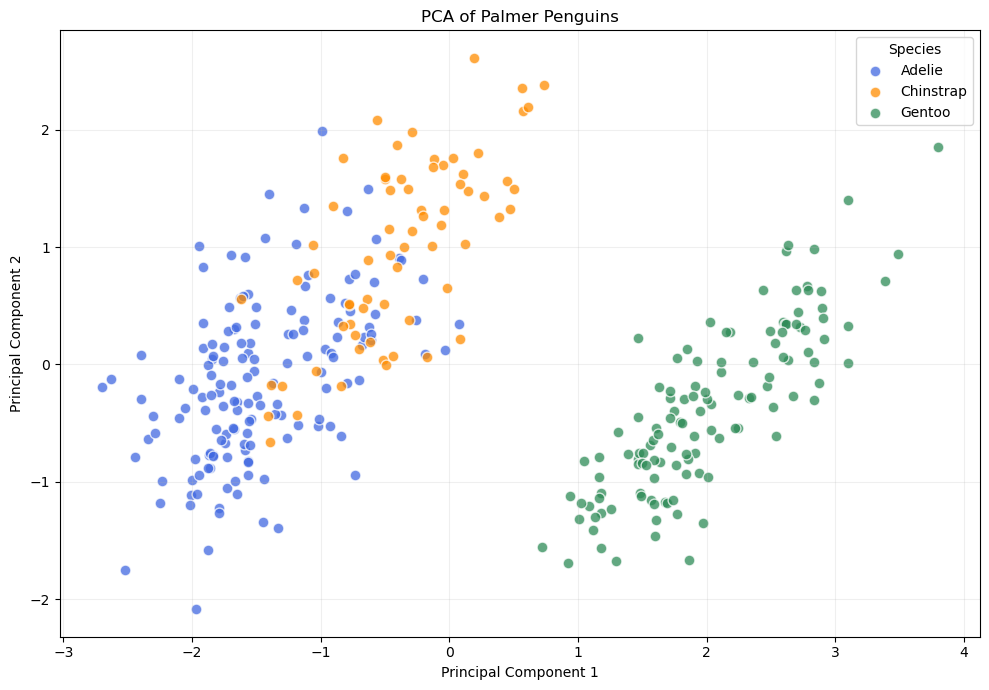

In [30]:
plt.figure(figsize=(10, 7))

colours = {
    "Adelie": "royalblue",
    "Chinstrap": "darkorange",
    "Gentoo": "seagreen",
}

for penguin_species, group in pca_results.groupby("species"):
    plt.scatter(
        group["principal_component_1"],
        group["principal_component_2"],
        label=penguin_species,
        color=colours.get(penguin_species),
        alpha=0.75,
        edgecolor="white",
        s=60,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Palmer Penguins")
plt.legend(title="Species")
plt.grid(alpha=0.2)
plt.tight_layout()

plot_path = "/tmp/penguins_pca.png"
plt.savefig(plot_path, dpi=150)
plt.show()